<a href="https://colab.research.google.com/github/raghavjoshi03/Machine-Learning/blob/main/Time_Series_Forecasting_with_RNN(LSTM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [77]:
df = pd.read_csv('/content/monthly-milk-production-pounds.csv', index_col = 'Month', parse_dates = True)
df.index.freq = 'MS'

In [78]:
df.head()

,Monthly milk production (pounds per cow)
Month,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


<Axes: xlabel='Month'>

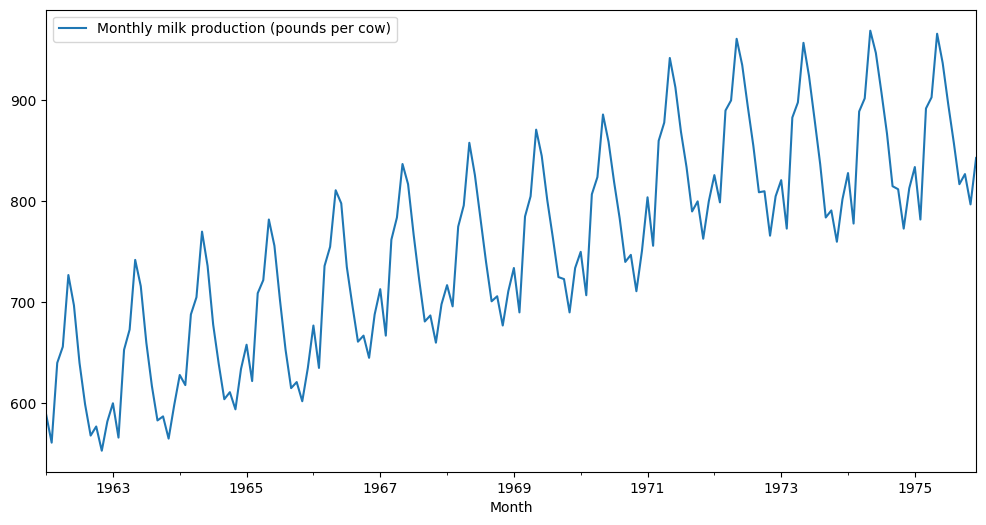

In [79]:
df.plot(figsize = (12, 6))

In [80]:
from statsmodels.tsa.seasonal import seasonal_decompose

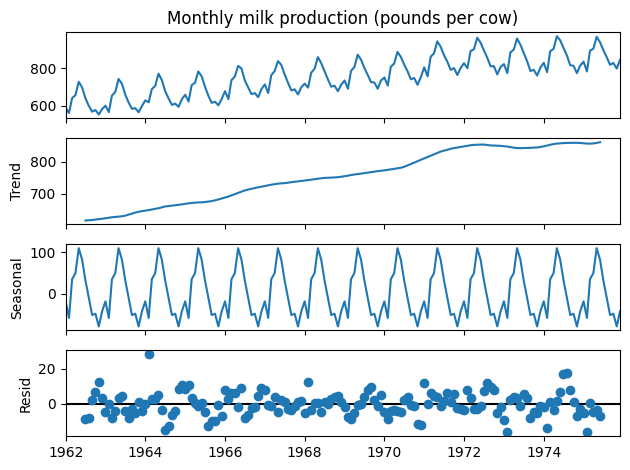

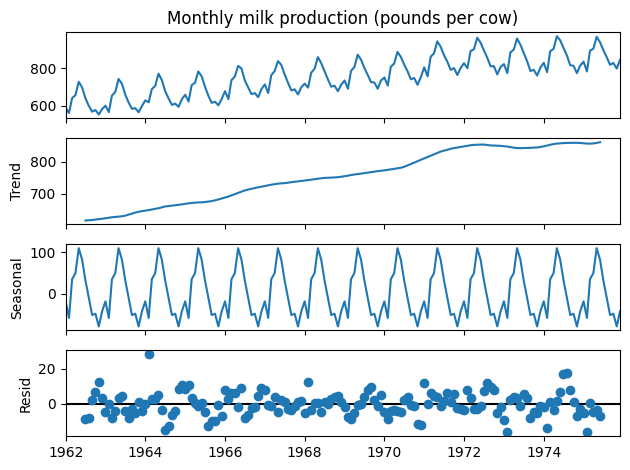

In [81]:
results = seasonal_decompose(df['Monthly milk production (pounds per cow)'])
results.plot()

In [82]:
len(df)

168

In [83]:
train = df.iloc[:156]
test = df.iloc[156:]

In [84]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [85]:
df.head, df.tail()

(<bound method NDFrame.head of             Monthly milk production (pounds per cow)
 Month                                               
 1962-01-01                                       589
 1962-02-01                                       561
 1962-03-01                                       640
 1962-04-01                                       656
 1962-05-01                                       727
 ...                                              ...
 1975-08-01                                       858
 1975-09-01                                       817
 1975-10-01                                       827
 1975-11-01                                       797
 1975-12-01                                       843
 
 [168 rows x 1 columns]>,
             Monthly milk production (pounds per cow)
 Month                                               
 1975-08-01                                       858
 1975-09-01                                       817
 1975-10-01             

In [86]:
scaler.fit(train)
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

In [87]:
scaled_train[:10]

array([[0.08653846],
       [0.01923077],
       [0.20913462],
       [0.24759615],
       [0.41826923],
       [0.34615385],
       [0.20913462],
       [0.11057692],
       [0.03605769],
       [0.05769231]])

In [88]:
!pip install keras

In [89]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [90]:
#define the generator
n_input = 3
n_features = 1
generator = TimeseriesGenerator(scaled_train, scaled_train, length = n_input, batch_size = 1)

In [91]:
print(len(scaled_train), len(generator))

156 153


In [92]:
x, y = generator[0]
print(f'Given the Array: \n{x.flatten()}')
print(f'Predict this y: \n {y}')

Given the Array: 
[0.08653846 0.01923077 0.20913462]
Predict this y: 
 [[0.24759615]]


In [93]:
x.shape

(1, 3, 1)

In [94]:
# We can do the same thing but instead of 12 months
n_input = 12
generator = TimeseriesGenerator(scaled_train, scaled_train, length = n_input, batch_size = 1)

In [95]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM

In [96]:
# define Model
model = Sequential()
model.add(LSTM(100, activation = 'relu', input_shape = (n_input, n_features)))
model.add(Dense(1))
model.compile(optimizer = 'adam', loss = 'mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [97]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [98]:
#fit model
model.fit(generator, epochs=50)

Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0545
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0209
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0130
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0250
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0085
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0066
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0053
Epoch 8/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0037
Epoch 9/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0046
Epoch 10/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0039
Epoch 11/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0041
Epoch 12/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0057
Epoch 13/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0034
Epoch 14/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0033
Epoch 15/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

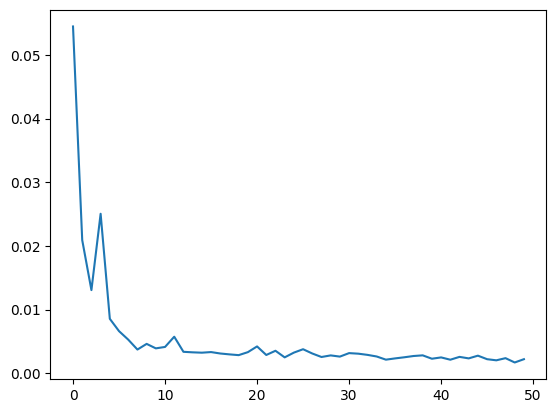

In [99]:
loss_per_epoch = model.history.history['loss']
plt.plot(range(len(loss_per_epoch)), loss_per_epoch)

In [100]:
last_train_batch = scaled_train[-12:]

In [101]:
last_train_batch = last_train_batch.reshape((1, n_input, n_features))

In [102]:
model.predict(last_train_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


array([[0.6214591]], dtype=float32)

In [104]:
scaled_test[0]

array([0.67548077])

In [105]:
test_predictions = []

first_eval_batch = scaled_train[-n_input:]
current_batch = first_eval_batch.reshape((1, n_input, n_features))

for i in range(len(test)):

  # Get the prediction value for the first batch
  curren_pred = model.predict(current_batch)[0]

  # Append the prediction into the array
  test_predictions.append(curren_pred)

  # Use the prediction to update the batch and remove the first value
  current_batch = np.append(current_batch[:, 1:, :], [[curren_pred]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [106]:
test_predictions

[array([0.6214591], dtype=float32),
 array([0.5983483], dtype=float32),
 array([0.7746854], dtype=float32),
 array([0.8455641], dtype=float32),
 array([0.931008], dtype=float32),
 array([0.91422963], dtype=float32),
 array([0.849073], dtype=float32),
 array([0.75174314], dtype=float32),
 array([0.6417176], dtype=float32),
 array([0.60262716], dtype=float32),
 array([0.5607943], dtype=float32),
 array([0.59020185], dtype=float32)]

In [107]:
test.head()

,Monthly milk production (pounds per cow)
Month,
1975-01-01,834
1975-02-01,782
1975-03-01,892
1975-04-01,903
1975-05-01,966


In [108]:
true_predictions = scaler.inverse_transform(test_predictions)

In [109]:
test['Predictions'] = true_predictions

/tmp/ipykernel_178/4269337381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


<Axes: xlabel='Month'>

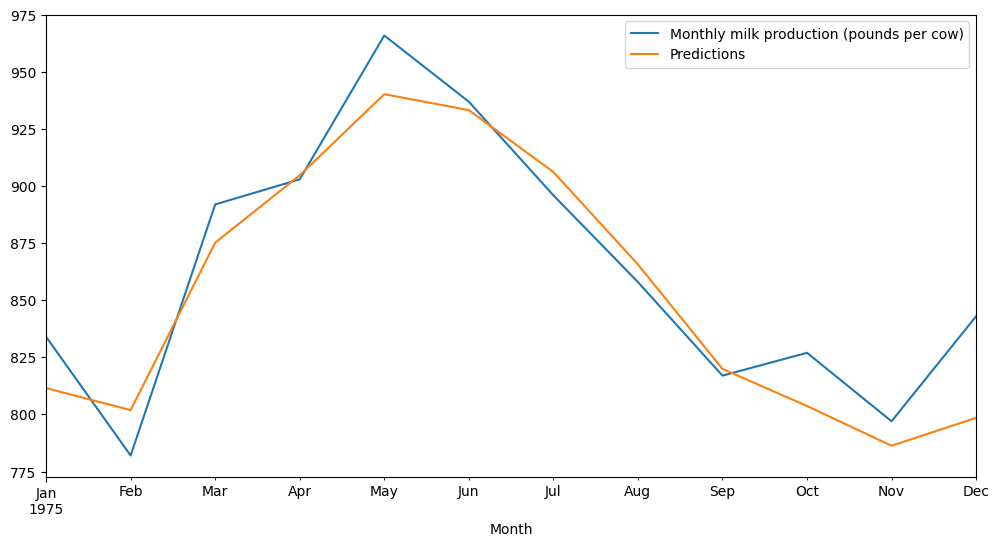

In [111]:
test.plot(figsize=(12, 6))

In [117]:
from sklearn.metrics import mean_squared_error
from math import sqrt
rmse = (mean_squared_error(test['Monthly milk production (pounds per cow)'], test['Predictions']))
print(rmse)

388.95041930285987
